# Trend Analysis Dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from utils import (
    fetch_prices, fetch_index,
    calc_monthly_returns,
    calc_trend_regime, calc_regime_stats,
    calc_trend_quintile,
    calc_momentum_signals, calc_quintile_from_signals,
    grid_search_regime, grid_search_quintile,
    plot_quadrant_scatter, plot_quadrant_trajectory, plot_regime_stats,
)

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

In [2]:
# ---- Configuration ----
proxy = None                                                # e.g. "http://proxy:8080"

# Ticker list & display names
tickers = [
    "SMH", "IGV", "XAR", "XBI", "XME", "GDX", "XOP", "PAVE",
    "MGK", "MGV", "IWM", "SCHD", "USMV", "MTUM", "QUAL",
    "372330.KS", "487230.KS", "BOTZ", "SKYY", "ICLN", "AIQ"
]

ticker_names = {
    "SMH":       "Semiconductors",
    "IGV":       "Software",
    "XAR":       "Aerospace",
    "XBI":       "Biotech",
    "XME":       "Metals&Mining",
    "GDX":       "GoldMiners",
    "XOP":       "Oil&Gas",
    "PAVE":      "InfraDev",
    "MGK":       "Growth",
    "MGV":       "Value",
    "IWM":       "Small",
    "SCHD":      "Dividend",
    "USMV":      "MinVol",
    "MTUM":      "Momentum",
    "QUAL":      "Quality",
    "372330.KS": "HangSengTech",
    "487230.KS": "AI-Power",
    "BOTZ":      "Robot",
    "SKYY":      "CloudComputing",
    "ICLN":      "CleanEnergy",
    "AIQ":       "AI-Tech"
}

# Trend lookback (months)
fast_months = 2
slow_months = 9

# Composite rank weights
w_slow = 0.5
w_fast = 0.5

# Snapshot date for Quadrant Scatter (None = latest available month-end)
# e.g. "2024-12-31" or "2024-12" — picks the nearest month-end ≤ this date
#snapshot_date = "2026-03-31"
snapshot_date = None

## 1. Trend Cycle Quadrant Analysis

In [3]:
prices_multi = fetch_prices(tickers, start="1900-01-01", end="2026-12-31", proxy=proxy)
monthly_ret_multi = calc_monthly_returns(prices_multi)
regimes = calc_trend_regime(monthly_ret_multi, fast_months=fast_months, slow_months=slow_months)

# Resolve snapshot date: None → latest, otherwise nearest month-end ≤ snapshot_date
all_dates = regimes["date"]
if snapshot_date is None:
    snap_date = all_dates.max()
else:
    target = pd.Timestamp(snapshot_date)
    eligible = all_dates[all_dates <= target]
    if len(eligible) == 0:
        raise ValueError(f"No regime data on/before {snapshot_date}; earliest available is {all_dates.min().date()}")
    snap_date = eligible.max()

latest_date = snap_date  # kept name for downstream cells
latest = regimes[regimes["date"] == latest_date].copy()

print(f"Snapshot date: {latest_date.strftime('%Y-%m-%d')}  (Fast={fast_months}M, Slow={slow_months}M)")
latest[["ticker", "ret_fast", "ret_slow", "regime"]]

[*********************100%***********************]  21 of 21 completed


Snapshot date: 2026-04-30  (Fast=2M, Slow=9M)


,ticker,ret_fast,ret_slow,regime
55,372330.KS,-0.022825,-0.042717,Bearish
68,487230.KS,0.220541,0.398383,Bullish
155,AIQ,0.084361,0.223865,Bullish
262,BOTZ,-0.034854,0.130045,Correction
493,GDX,-0.235670,0.727015,Correction
699,ICLN,0.088913,0.491004,Bullish
988,IGV,0.042050,-0.238761,Rebound
1291,IWM,0.049681,0.258482,Bullish
1503,MGK,0.082748,0.102931,Bullish
1715,MGV,-0.014447,0.167652,Correction


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


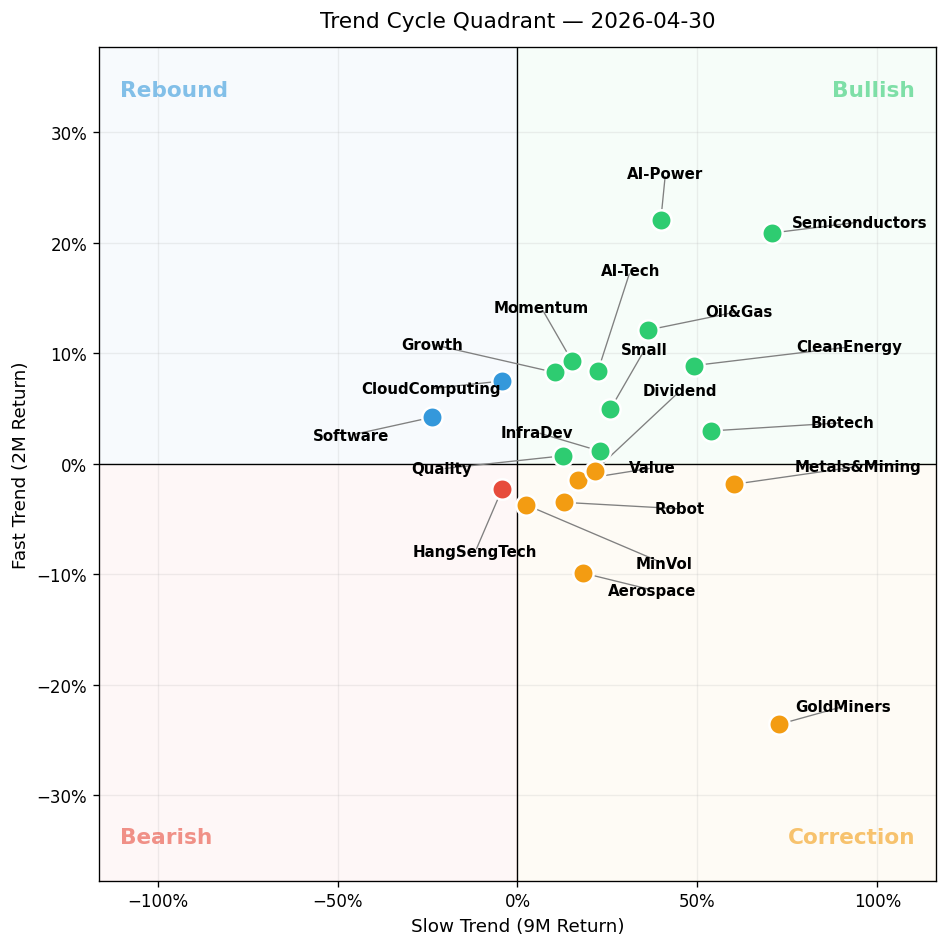

In [4]:
# Chart A: Quadrant Scatter
plot_quadrant_scatter(latest, snap_date=latest_date, ticker_names=ticker_names,
                      fast_months=fast_months, slow_months=slow_months)
plt.show()

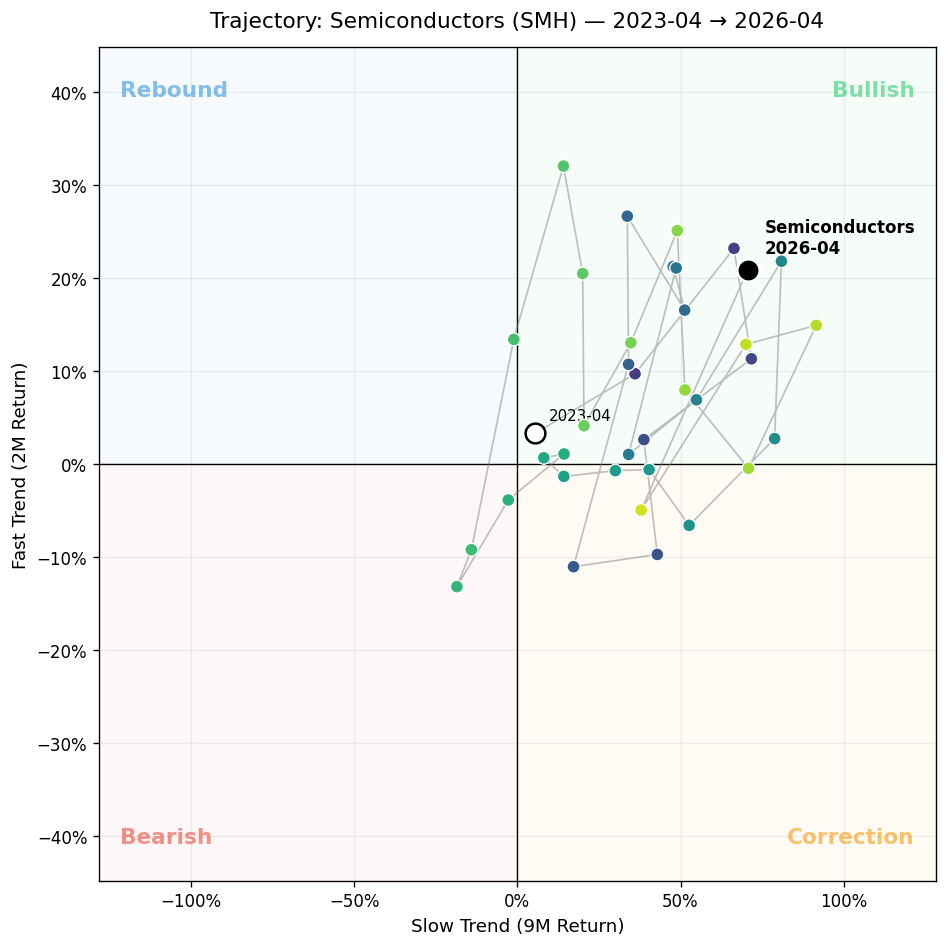

In [5]:
# Chart A2: Single-ticker trajectory through the quadrant
trajectory_ticker = "SMH"          # change to any ticker in the universe
trajectory_start = None            # e.g. "2022-01-31" (None → use lookback)
trajectory_end = snapshot_date     # None → latest available
trajectory_lookback = 36           # months back from end (ignored if start is set)

plot_quadrant_trajectory(
    regimes, ticker=trajectory_ticker, ticker_names=ticker_names,
    fast_months=fast_months, slow_months=slow_months,
    start_date=trajectory_start, end_date=trajectory_end,
    lookback_months=trajectory_lookback,
)
plt.show()

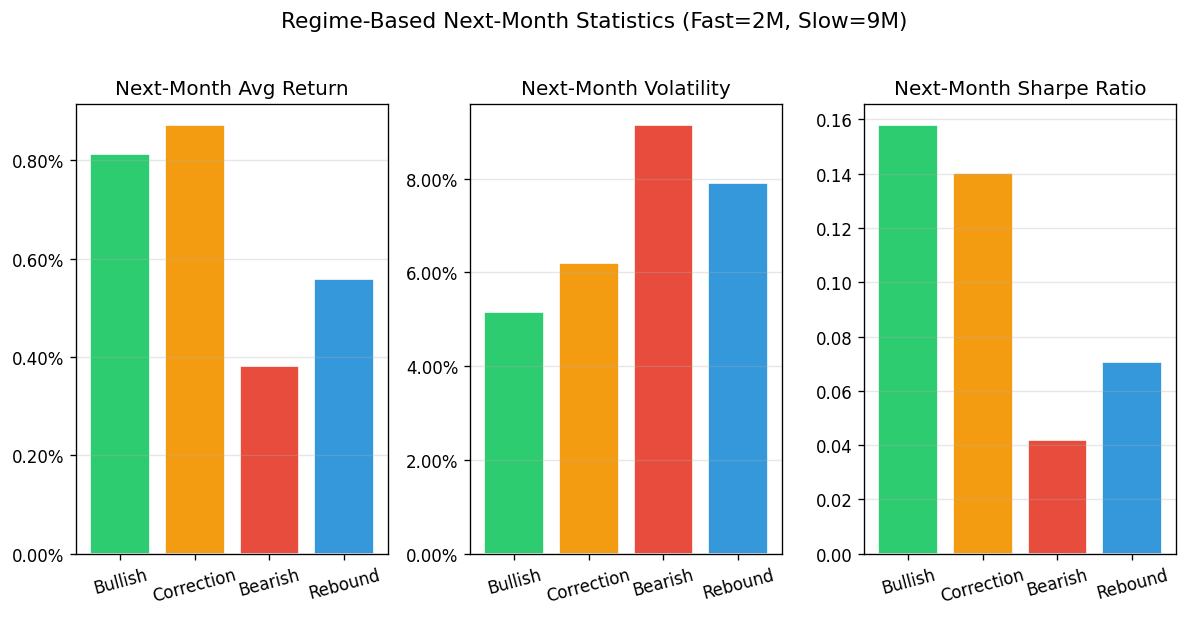

In [6]:
# Chart B: Regime Statistics
regime_stats = calc_regime_stats(monthly_ret_multi, regimes)
plot_regime_stats(regime_stats, fast_months=fast_months, slow_months=slow_months)
plt.show()

## 2. Trend Quintile Analysis (Rank-Based)

In [7]:
# Quintile assignment
quintile_latest, quintile_stats = calc_trend_quintile(
    monthly_ret_multi, regimes, w_slow=w_slow, w_fast=w_fast
)

# Show current quintile assignments
quintile_latest["name"] = quintile_latest["ticker"].map(ticker_names)
display(quintile_latest[["ticker", "name", "ret_fast", "ret_slow",
                          "rank_slow", "rank_fast", "rank_composite", "quintile"]]
        .sort_values("rank_composite"))
print(f"\nLookback: Fast={fast_months}M, Slow={slow_months}M | Weights: Slow={w_slow}, Fast={w_fast}")
quintile_stats

,ticker,name,ret_fast,ret_slow,rank_slow,rank_fast,rank_composite,quintile
55,372330.KS,HangSengTech,-0.022825,-0.042717,2.0,5.0,3.5,Q1
2912,USMV,MinVol,-0.037256,0.024967,4.0,3.0,3.5,Q1
262,BOTZ,Robot,-0.034854,0.130045,7.0,4.0,5.5,Q1
3079,XAR,Aerospace,-0.098677,0.180973,10.0,2.0,6.0,Q1
988,IGV,Software,0.042050,-0.238761,1.0,12.0,6.5,Q2
2109,QUAL,Quality,0.007273,0.126937,6.0,9.0,7.5,Q2
1715,MGV,Value,-0.014447,0.167652,9.0,7.0,8.0,Q2
2444,SKYY,CloudComputing,0.074966,-0.042486,3.0,14.0,8.5,Q2
2275,SCHD,Dividend,-0.006143,0.215221,11.0,8.0,9.5,Q3
1503,MGK,Growth,0.082748,0.102931,5.0,15.0,10.0,Q3



Lookback: Fast=2M, Slow=9M | Weights: Slow=0.5, Fast=0.5


,mean,std,sharpe
Q1,0.002429,0.076943,0.031565
Q2,0.008768,0.059597,0.147122
Q3,0.012434,0.062563,0.198747
Q4,0.012176,0.055314,0.220127
Q5,0.010019,0.059632,0.168007


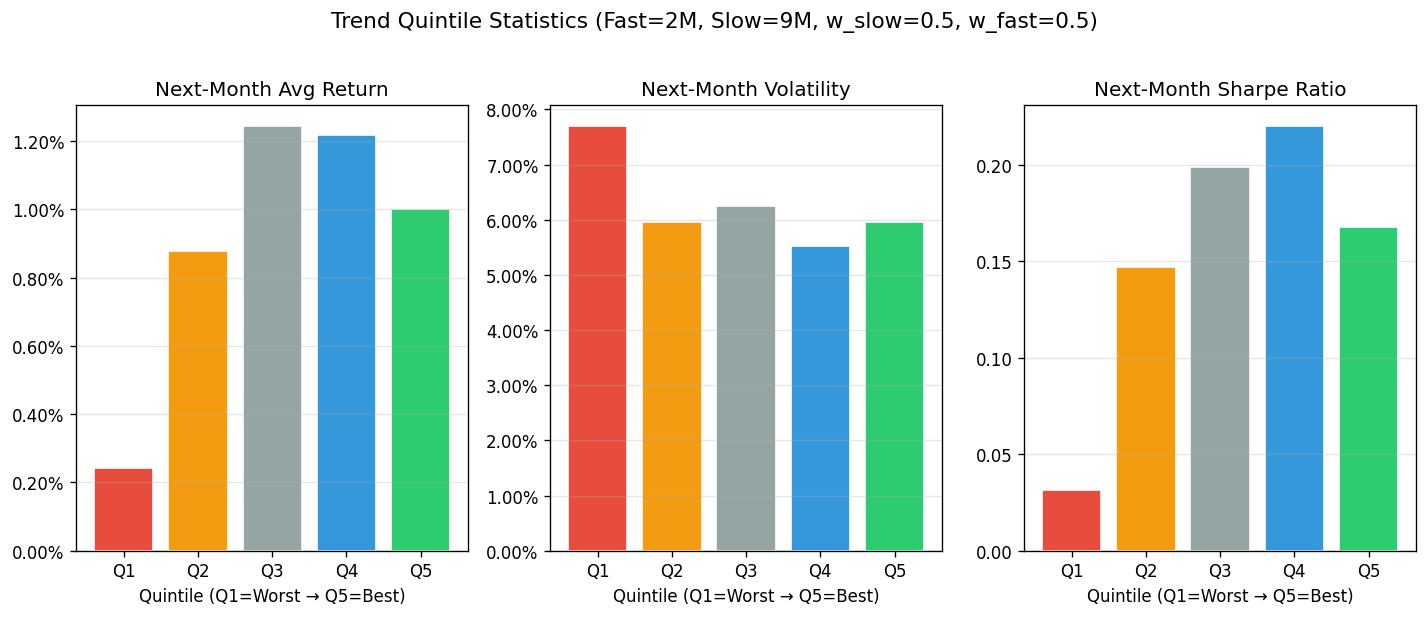

In [8]:
# Chart: Quintile Statistics
q_labels = [f"Q{i}" for i in range(1, 6)]
q_colors = ["#e74c3c", "#f39c12", "#95a5a6", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Mean Return
axes[0].bar(q_labels, quintile_stats.loc[q_labels, "mean"], color=q_colors, edgecolor="white")
axes[0].set_title("Next-Month Avg Return")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(axis="y", alpha=0.3)

# Volatility
axes[1].bar(q_labels, quintile_stats.loc[q_labels, "std"], color=q_colors, edgecolor="white")
axes[1].set_title("Next-Month Volatility")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[1].grid(axis="y", alpha=0.3)

# Sharpe
axes[2].bar(q_labels, quintile_stats.loc[q_labels, "sharpe"], color=q_colors, edgecolor="white")
axes[2].set_title("Next-Month Sharpe Ratio")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.set_xlabel("Quintile (Q1=Worst → Q5=Best)")

plt.suptitle(f"Trend Quintile Statistics (Fast={fast_months}M, Slow={slow_months}M, w_slow={w_slow}, w_fast={w_fast})", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Grid Search — Optimal Fast/Slow Lookback

### 3a. Regime monotonicity (Bull > Rebound ≈ Correction > Bear)

In [9]:
%%time
# Grid search: regime sharpe monotonicity
# Ideal: Bullish > Rebound ≈ Correction > Bearish (in next-month sharpe)
# Violations counted (max 4): bull>rebound, bull>corr, rebound>bear, corr>bear
regime_grid = grid_search_regime(
    monthly_ret_multi,
    fast_list=[1, 2, 3],
    slow_list=[6, 9, 10, 11, 12],
)

n_mono_r = regime_grid["is_monotonic"].sum()
n_near_r = (regime_grid["regime_violations"] <= 1).sum()
print(f"Total combos tested: {len(regime_grid)}")
print(f"Strictly monotonic (0 violations): {n_mono_r}")
print(f"Near-monotonic (≤1 violation): {n_near_r}")

near_regime = regime_grid[regime_grid["regime_violations"] <= 1]
print(f"\nTop 15 near-monotonic combos:")
near_regime[["fast_months", "slow_months",
             "sharpe_Bullish", "sharpe_Rebound", "sharpe_Correction", "sharpe_Bearish",
             "bull_bear_spread", "regime_violations"]].head(15)

Total combos tested: 15
Strictly monotonic (0 violations): 4
Near-monotonic (≤1 violation): 12

Top 15 near-monotonic combos:
CPU times: user 10.2 s, sys: 0 ns, total: 10.2 s
Wall time: 10.5 s


,fast_months,slow_months,sharpe_Bullish,sharpe_Rebound,sharpe_Correction,sharpe_Bearish,bull_bear_spread,regime_violations
0,2,9,0.157780,0.070774,0.140372,0.041822,0.115958,0
1,3,10,0.186322,0.090912,0.163936,0.073462,0.112860,0
2,2,10,0.170220,0.099733,0.157140,0.066208,0.104012,0
3,2,6,0.140182,0.116832,0.089950,0.066863,0.073319,0
4,2,11,0.187806,0.097731,0.200141,0.021254,0.166552,1
5,3,11,0.185076,0.089476,0.199469,0.019398,0.165678,1
6,3,12,0.193739,0.117924,0.201023,0.032371,0.161368,1
7,2,12,0.160220,0.133936,0.208850,0.029789,0.130432,1
8,3,9,0.182738,0.055328,0.143209,0.064212,0.118526,1
9,1,11,0.113794,0.090357,0.251408,0.002223,0.111570,1


### 3b. Quintile monotonicity (Q1 < Q2 < Q3 < Q4 < Q5)

In [10]:
%%time
# Grid search: find combo that maximizes Q5-Q1 Sharpe spread
# Results sorted by: (1) fewest monotonicity violations, (2) largest spread
grid_results = grid_search_quintile(
    monthly_ret_multi,
    fast_list=[1, 2, 3],
    slow_list=[6, 9, 10, 11, 12],
    weight_step=0.1,
)

n_mono = grid_results["is_monotonic"].sum()
n_near = (grid_results["mono_violations"] <= 1).sum()
print(f"Total combos tested: {len(grid_results)}")
print(f"Strictly monotonic (0 violations): {n_mono}")
print(f"Near-monotonic (≤1 violation): {n_near}")

# Show near-monotonic combos (≤1 violation), sorted by spread
near_mono = grid_results[grid_results["mono_violations"] <= 1]
print(f"\nTop 15 near-monotonic combos:")
near_mono[["fast_months", "slow_months", "w_slow", "w_fast",
           "sharpe_Q1", "sharpe_Q2", "sharpe_Q3", "sharpe_Q4", "sharpe_Q5",
           "sharpe_spread", "mono_violations"]].head(15)

Total combos tested: 165
Strictly monotonic (0 violations): 0
Near-monotonic (≤1 violation): 107

Top 15 near-monotonic combos:
CPU times: user 2min 2s, sys: 0 ns, total: 2min 2s
Wall time: 2min 2s


,fast_months,slow_months,w_slow,w_fast,sharpe_Q1,sharpe_Q2,sharpe_Q3,sharpe_Q4,sharpe_Q5,sharpe_spread,mono_violations
0,1,6,0.5,0.5,0.055512,0.145352,0.219634,0.193802,0.227627,0.172115,1
1,2,12,0.2,0.8,0.037084,0.161958,0.179845,0.213013,0.203601,0.166517,1
2,2,6,0.2,0.8,0.038572,0.174785,0.189784,0.236493,0.201400,0.162827,1
3,2,10,0.1,0.9,0.047304,0.156682,0.176695,0.216675,0.208214,0.160910,1
4,2,10,0.2,0.8,0.043568,0.142497,0.176295,0.223913,0.203644,0.160077,1
5,2,9,0.1,0.9,0.053141,0.155746,0.173457,0.216130,0.212559,0.159418,1
6,2,6,0.3,0.7,0.032446,0.146401,0.218926,0.241923,0.191166,0.158721,1
7,2,6,0.1,0.9,0.055566,0.156507,0.177158,0.224809,0.214156,0.158590,1
8,1,6,0.6,0.4,0.043921,0.179358,0.182925,0.239244,0.202375,0.158454,1
9,2,12,0.1,0.9,0.041842,0.166336,0.178414,0.201812,0.199357,0.157515,1


Best combo (near-monotonic (1 violation)): Fast=1M, Slow=6M, w_slow=0.5, w_fast=0.5
  Q1→Q5 Sharpe: 0.056 → 0.145 → 0.220 → 0.194 → 0.228
  Spread: 0.172


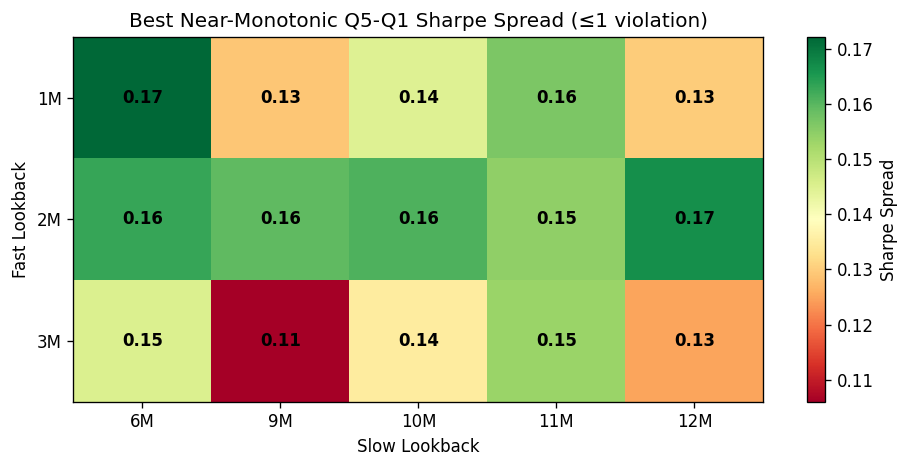

In [11]:
# Visualize grid search results
# Pick best: strictly monotonic first, then ≤1 violation, then best overall
mono_results = grid_results[grid_results["is_monotonic"]]
near_results = grid_results[grid_results["mono_violations"] <= 1]

if len(mono_results) > 0:
    best = mono_results.iloc[0]
    label = "monotonic"
elif len(near_results) > 0:
    best = near_results.iloc[0]
    label = f"near-monotonic ({int(best['mono_violations'])} violation)"
else:
    best = grid_results.iloc[0]
    label = f"{int(best['mono_violations'])} violations"

print(f"Best combo ({label}): "
      f"Fast={int(best['fast_months'])}M, Slow={int(best['slow_months'])}M, "
      f"w_slow={best['w_slow']:.1f}, w_fast={best['w_fast']:.1f}")
print(f"  Q1→Q5 Sharpe: {best['sharpe_Q1']:.3f} → {best['sharpe_Q2']:.3f} → "
      f"{best['sharpe_Q3']:.3f} → {best['sharpe_Q4']:.3f} → {best['sharpe_Q5']:.3f}")
print(f"  Spread: {best['sharpe_spread']:.3f}")

# Heatmap: for each (fast, slow) pair, show best sharpe_spread among ≤1 violation combos
pivot_src = near_results if len(near_results) > 0 else grid_results
hm_pivot = pivot_src.groupby(["fast_months", "slow_months"])["sharpe_spread"].max().unstack()

if not hm_pivot.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(hm_pivot.values, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(hm_pivot.columns)))
    ax.set_xticklabels([f"{int(c)}M" for c in hm_pivot.columns])
    ax.set_yticks(range(len(hm_pivot.index)))
    ax.set_yticklabels([f"{int(r)}M" for r in hm_pivot.index])
    ax.set_xlabel("Slow Lookback")
    ax.set_ylabel("Fast Lookback")
    ax.set_title("Best Near-Monotonic Q5-Q1 Sharpe Spread (≤1 violation)")

    for i in range(len(hm_pivot.index)):
        for j in range(len(hm_pivot.columns)):
            val = hm_pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, fontweight="bold")

    plt.colorbar(im, ax=ax, label="Sharpe Spread")
    plt.tight_layout()
    plt.show()

Selected: #0 → Fast=1M, Slow=6M, w_slow=0.5, w_fast=0.5  (violations=1, spread=0.172)


,ticker,name,ret_fast,ret_slow,rank_slow,rank_fast,rank_composite,quintile
58,372330.KS,HangSengTech,0.020619,-0.152657,3.0,6.0,4.5,Q1
1009,IGV,Software,0.061836,-0.264133,1.0,9.0,5.0,Q1
3133,XAR,Aerospace,0.003662,0.026526,7.0,3.0,5.0,Q1
2963,USMV,MinVol,0.011214,0.014768,6.0,4.0,5.0,Q1
2489,SKYY,CloudComputing,0.077816,-0.172784,2.0,11.0,6.5,Q2
1745,MGV,Value,0.035323,0.105351,11.0,8.0,9.5,Q2
2148,QUAL,Quality,0.073510,0.054423,9.0,10.0,9.5,Q2
508,GDX,GoldMiners,-0.035197,0.237622,18.0,2.0,10.0,Q2
2317,SCHD,Dividend,0.020535,0.192440,16.0,5.0,10.5,Q3
274,BOTZ,Robot,0.133654,-0.000195,5.0,16.0,10.5,Q3


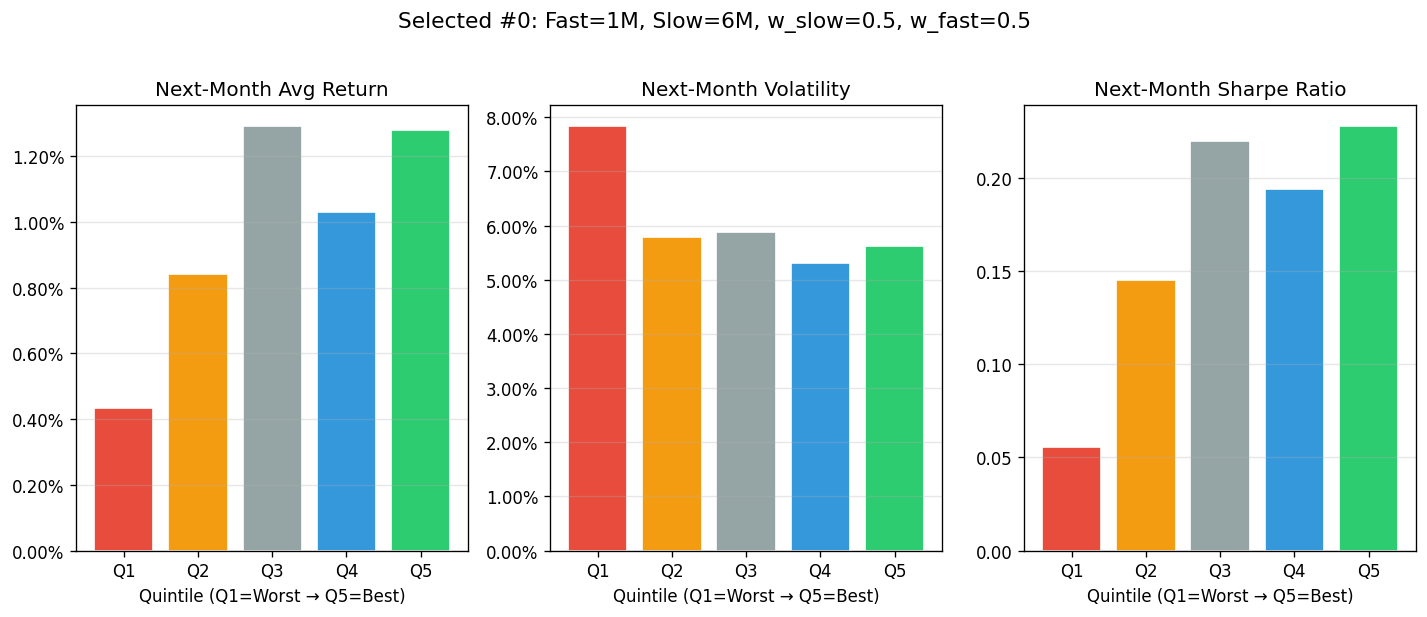

In [12]:
# ---- Select combo from near-monotonic results (0-indexed from table above) ----
selected_rank = 0  # Change this: 0 = 1st row, 2 = 3rd row, etc.

# Rerun quintile analysis with selected combo from grid search
sel = near_mono.iloc[selected_rank]
sel_fast = int(sel["fast_months"])
sel_slow = int(sel["slow_months"])
sel_ws = sel["w_slow"]
sel_wf = sel["w_fast"]

print(f"Selected: #{selected_rank} → Fast={sel_fast}M, Slow={sel_slow}M, "
      f"w_slow={sel_ws:.1f}, w_fast={sel_wf:.1f}  "
      f"(violations={int(sel['mono_violations'])}, spread={sel['sharpe_spread']:.3f})")

sel_signals = calc_momentum_signals(monthly_ret_multi, fast_months=sel_fast, slow_months=sel_slow)
sel_q_latest, sel_q_stats = calc_quintile_from_signals(
    monthly_ret_multi, sel_signals, w_slow=sel_ws, w_fast=sel_wf
)

# Show assignments
sel_q_latest["name"] = sel_q_latest["ticker"].map(ticker_names)
display(sel_q_latest[["ticker", "name", "ret_fast", "ret_slow",
                       "rank_slow", "rank_fast", "rank_composite", "quintile"]]
        .sort_values("rank_composite"))

# Chart
q_labels = [f"Q{i}" for i in range(1, 6)]
q_colors = ["#e74c3c", "#f39c12", "#95a5a6", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].bar(q_labels, sel_q_stats.loc[q_labels, "mean"], color=q_colors, edgecolor="white")
axes[0].set_title("Next-Month Avg Return")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(q_labels, sel_q_stats.loc[q_labels, "std"], color=q_colors, edgecolor="white")
axes[1].set_title("Next-Month Volatility")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=2))
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(q_labels, sel_q_stats.loc[q_labels, "sharpe"], color=q_colors, edgecolor="white")
axes[2].set_title("Next-Month Sharpe Ratio")
axes[2].axhline(0, color="black", linewidth=0.5)
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.set_xlabel("Quintile (Q1=Worst → Q5=Best)")

plt.suptitle(f"Selected #{selected_rank}: Fast={sel_fast}M, Slow={sel_slow}M, "
             f"w_slow={sel_ws:.1f}, w_fast={sel_wf:.1f}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()